# Replicating the Italian day-ahead market with OpenEUPHEMIA

[EUPHEMIA](https://www.nemo-committee.eu/sdac) clears the European day-ahead
market: it maximizes welfare over every submitted order subject to network
constraints, and the outcome — a price per zone, a flow per link — settles
billions of euros a year. It's publicly described but closed-source.

Here we build the seven Italian bidding zones by hand for one day, then
compare five ways of closing the model at the border against a full month
of published results.

In [1]:
import pathlib
import sys

if "google.colab" in sys.modules:
    !git clone -q https://github.com/rebase-energy/OpenEUPHEMIA.git
    %pip install -q "./OpenEUPHEMIA[notebook]"
    ROOT = pathlib.Path("OpenEUPHEMIA")
else:
    ROOT = next(
        parent
        for parent in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
        if (parent / "data" / "italy").is_dir()
    )

sys.path.insert(0, str(ROOT / "src"))
DATA = ROOT / "data" / "italy" / "2025-04"
print("repository root:", ROOT)

repository root: /Users/sebaheg/Documents/Github/OpenEUPHEMIA


## The inputs

Six tidy tables from GME's public publications, committed under
[`data/italy`](../data/italy) — no data-collection code, just datasets.
The Italian prices and the flows between Italian zones are the targets
and are never given to the solver.

| Table | What it is |
|---|---|
| `bid-curves` | order book, aggregated: zone, hour, side, price step |
| `transfer-capacities` | link limit, internal and cross-border |
| `internal-transfer-capacities` | the 6 internal links, shaped for `set_ntc` |
| `published-prices` | Italian zones **and** their neighbours |
| `published-exchanges` | scheduled exchange, each of the 12 borders |
| `published-flows` | scheduled flow, each of the 6 internal links — **target** |

In [2]:
import pandas as pd

bid_curves = pd.read_csv(DATA / "bid-curves.csv.gz")
transfer_capacities = pd.read_csv(DATA / "transfer-capacities.csv.gz")
internal_capacities = pd.read_csv(DATA / "internal-transfer-capacities.csv.gz")
published_prices = pd.read_csv(DATA / "published-prices.csv.gz")
published_exchanges = pd.read_csv(DATA / "published-exchanges.csv.gz")
published_flows = pd.read_csv(DATA / "published-flows.csv.gz")

DAY = "2025-04-01"
print(f"{len(bid_curves):,} curve rows over {bid_curves.delivery_day.nunique()} days")

535,765 curve rows over 30 days


## Build one day by hand

Zones and links on the `PowerMarket` itself, aggregated bid curves per
zone and hour, then `set_ntc` for the internal transfer limits.

In [3]:
from openeuphemia import PowerMarket, bid_curves_from_table
from openeuphemia.areas.italy import ITALY_PRICE_AREAS
from openeuphemia.areas.italy.replication import rows_for_day

links = sorted({(r.from_zone, r.to_zone) for r in internal_capacities.itertuples()})

market = PowerMarket(
    name="italy", delivery_day=DAY, zones=list(ITALY_PRICE_AREAS),
    interconnectors=links, periods=list(range(1, 25)),
)
curves = bid_curves_from_table(rows_for_day(bid_curves, DAY))
for (period, zone), sides in curves.items():
    market.add_bid_curve(zone=zone, period=period, **sides)
for row in rows_for_day(internal_capacities, DAY).itertuples():
    market.set_ntc(row.from_zone, row.to_zone, period=row.period,
                    forward_capacity_mwh=row.forward_capacity_mwh,
                    reverse_capacity_mwh=row.reverse_capacity_mwh)

print(f"{len(curves)} zone-hours -> {len(market.orders):,} orders")

168 zone-hours -> 18,060 orders


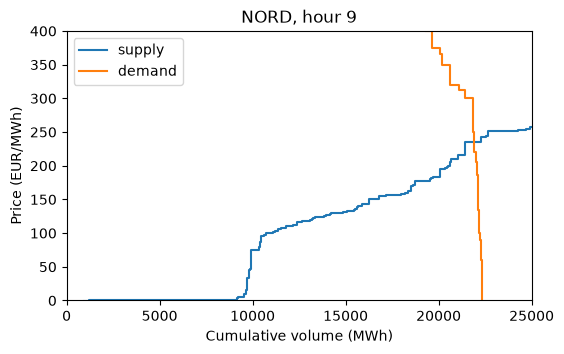

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3.5))
curves[(9, "NORD")]["supply"].plot(ax=ax, label="supply")
curves[(9, "NORD")]["demand"].plot(ax=ax, label="demand")
ax.set_xlim(0, 25_000); ax.set_ylim(0, 400)
ax.set_title("NORD, hour 9"); ax.legend()
plt.show()

## Close the border, clear, compare

Italy trades with six neighbours. `add_price_boundary` makes each border
a *price taker* at the neighbour's published price — free to trade within
the published capacity, no exchange data needed. (`add_flow_boundary` is
the other option: pin a border at a known exchange instead.)

In [5]:
from openeuphemia.areas.italy import compare_prices, summarize_price_comparison
from openeuphemia.areas.italy.replication import (
    external_boundary_prices, external_capacity_bounds, price_mapping,
)

prices_by_zone = price_mapping(published_prices, delivery_day=DAY)
neighbour_prices = {k: v for k, v in prices_by_zone.items() if k[1] not in ITALY_PRICE_AREAS}
border_prices, _ = external_boundary_prices(
    external_capacity_bounds(transfer_capacities, delivery_day=DAY, zones=ITALY_PRICE_AREAS),
    neighbour_prices,
)
for row in border_prices.itertuples():
    market.add_price_boundary(
        id=row.id, period=row.period, zone=row.zone, external_zone=row.external_zone,
        price_eur_per_mwh=row.price_eur_per_mwh,
        import_capacity_mwh=row.import_capacity_mwh, export_capacity_mwh=row.export_capacity_mwh,
    )

result = market.clear(method="per-period-lp")
italian_prices = {k: v for k, v in prices_by_zone.items() if k[1] in ITALY_PRICE_AREAS}
comparison = compare_prices(result.prices, italian_prices, delivery_day=DAY)
summarize_price_comparison(comparison)

{'price_rows': 168,
 'matched_rows': 168,
 'exact_rows': 168,
 'price_mae_eur_per_mwh': 0.0,
 'price_max_abs_error_eur_per_mwh': 0.0}

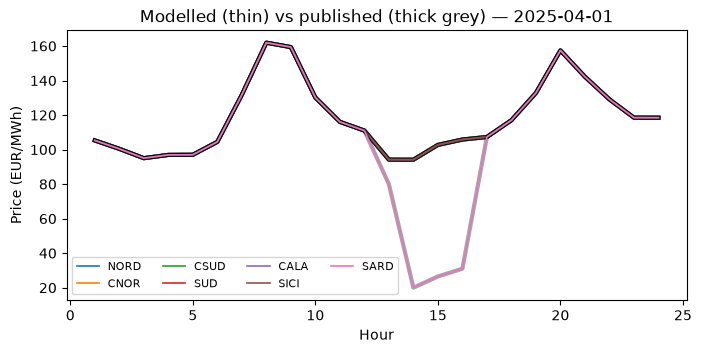

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
for zone in ITALY_PRICE_AREAS:
    rows = comparison[comparison.zone == zone].sort_values("period")
    ax.plot(rows.period, rows.published_price_eur_per_mwh, lw=3, alpha=0.35, color="black")
    ax.plot(rows.period, rows.modelled_price_eur_per_mwh, lw=1.2, label=zone)
ax.set_xlabel("Hour"); ax.set_ylabel("Price (EUR/MWh)")
ax.set_title(f"Modelled (thin) vs published (thick grey) — {DAY}")
ax.legend(ncol=4, fontsize=8)
plt.show()

168 of 168 hours exact — welfare maximization pins down a unique price,
and the neighbours' published prices alone stand in for the rest of Europe.

## Five ways to close the model, one month

Prices are solved. Flows are not: whenever two zones share a price, the
exchange between them is genuinely indeterminate, so which flow the model
returns depends on how the border is closed and — if it's pinned — which
tie-breaking rule fills in the rest. `replicate_italy_day` runs the exact
steps above end to end; `boundary` and `flow_selection` are its two knobs.

| Case | Boundary | Rule |
|---|---|---|
| A | price-taking | — |
| B | fixed exchange | — |
| C | fixed exchange | `volume-max` (documented) |
| D | fixed exchange | `pro-rata` (learned) |
| E | fixed exchange | `anchored` (reads the answer) |

In [7]:
from openeuphemia.areas.italy import delivery_days, replicate_italy_day, summarize_flow_comparison

CASES = [
    ("A. price-taking", "prices", None),
    ("B. fixed exchange", "exchanges", None),
    ("C. + volume-max", "exchanges", "volume-max"),
    ("D. + pro-rata", "exchanges", "pro-rata"),
    ("E. + anchored", "exchanges", "anchored"),
]
inputs = dict(
    bid_curves=bid_curves, transfer_capacities=transfer_capacities,
    published_prices=published_prices, published_flows=published_flows,
    published_exchanges=published_exchanges,
)
days = delivery_days(bid_curves)

price_errors, flow_errors, overview = {}, {}, []
for name, boundary, rule in CASES:
    results = [
        replicate_italy_day(delivery_day=day, boundary=boundary, flow_selection=rule, **inputs)
        for day in days
    ]
    prices = pd.concat([r.price_comparison for r in results], ignore_index=True)
    flows = pd.concat([r.flow_comparison for r in results], ignore_index=True)
    price_errors[name], flow_errors[name] = prices, flows
    overview.append({
        "case": name,
        "price MAE (EUR/MWh)": summarize_price_comparison(prices)["price_mae_eur_per_mwh"],
        "flow MAE (MWh)": summarize_flow_comparison(flows)["flow_mae_mwh"],
    })

pd.DataFrame(overview)

,case,price MAE (EUR/MWh),flow MAE (MWh)
0,A. price-taking,0.000000,2065.281395
1,B. fixed exchange,0.159754,2.891404
2,C. + volume-max,0.159754,2.901284
3,D. + pro-rata,0.159754,0.001155
4,E. + anchored,0.159754,0.000087


## Where the error sits

Prices by zone, flows by interconnector, log scale (exact results sit at
the floor). Prices depend only on the boundary, not the flow rule, so
C/D/E are omitted on the left — their bars equal B's.

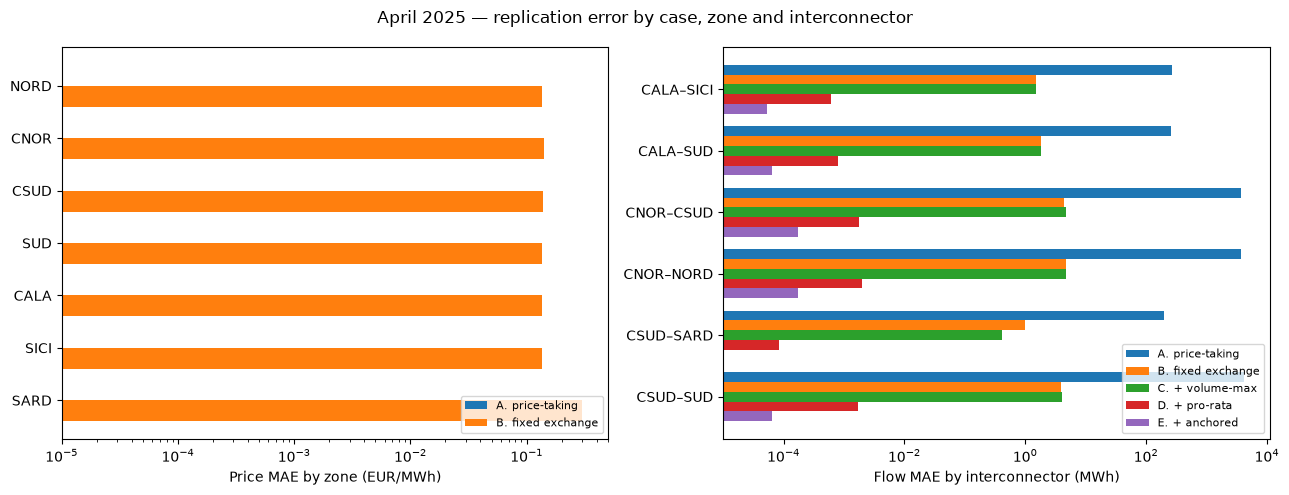

In [8]:
import numpy as np

FLOOR = 1e-5

def mae_by(frame, col, error_col):
    return frame.groupby(col)[error_col].mean()

zones = list(ITALY_PRICE_AREAS)
price_cases = [CASES[0][0], CASES[1][0]]
flow_cases = [name for name, _b, _r in CASES]
links_x = sorted({f"{a}–{b}" for a, b in zip(flow_errors[CASES[1][0]].from_zone,
                                             flow_errors[CASES[1][0]].to_zone)})

fig, (left, right) = plt.subplots(1, 2, figsize=(13, 5))

height = 0.8 / len(price_cases)
for i, case in enumerate(price_cases):
    values = mae_by(price_errors[case], "zone", "absolute_error_eur_per_mwh")
    left.barh(np.arange(len(zones)) + i * height,
              [max(values.get(z, 0.0), FLOOR) for z in zones], height=height, label=case)
left.set_yticks(np.arange(len(zones)) + 0.4 - height / 2, zones)
left.set_xscale("log"); left.set_xlim(FLOOR, None)
left.set_xlabel("Price MAE by zone (EUR/MWh)"); left.invert_yaxis()
left.legend(fontsize=8, loc="lower right")

height = 0.8 / len(flow_cases)
for i, case in enumerate(flow_cases):
    frame = flow_errors[case].assign(link=lambda f: f.from_zone + "–" + f.to_zone)
    values = mae_by(frame, "link", "absolute_error_mwh")
    right.barh(np.arange(len(links_x)) + i * height,
               [max(values.get(l, 0.0), FLOOR) for l in links_x], height=height, label=case)
right.set_yticks(np.arange(len(links_x)) + 0.4 - height / 2, links_x)
right.set_xscale("log"); right.set_xlim(FLOOR, None)
right.set_xlabel("Flow MAE by interconnector (MWh)"); right.invert_yaxis()
right.legend(fontsize=8, loc="lower right")

fig.suptitle("April 2025 — replication error by case, zone and interconnector")
plt.tight_layout()
plt.show()

## What this shows

| Outcome | Best case | Result |
|---|---|---|
| Prices | A | 5,040 / 5,040 zone-hours exact, MAE 0.0000 EUR/MWh |
| Flows | D | 0.0012 MWh MAE over 4,320 link-hours |

Prices follow from welfare maximization alone. Flows need a rule on top,
because the optimization genuinely leaves them open, and pro-rata — the
rule that closes the gap — isn't in EUPHEMIA's public description:

- it was reverse-engineered from published outcomes, not specified;
- it's era-dependent — before the 2025 abolition of the PUN, the
  documented merit-order priority rule fits instead.

The same tables — curves, capacities, border prices and exchanges — are
what any other bidding zone needs. Adding a region means preparing them
and proving the clearing reproduces what was published.